# Quickstart: ECCC HRDPS forecast - dynamical.org Icechunk Zarr

HRDPS is the High Resolution Deterministic Prediction System, Environment and Climate Change Canada's convection-permitting model. The continental domain covers Canada at 2.5 km resolution, with a new forecast every 6 hours, and an hourly forecast step out to 48 hours.

Dataset documentation: https://dynamical.org/catalog/eccc-hrdps-forecast/

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/). Processed by dynamical.org from ECCC data under the [ECCC Data Servers End-use Licence 2.1](https://eccc-msc.github.io/open-data/licence/readme_en/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
import icechunk
import xarray as xr

# Not in the STAC catalog yet. Once it is, this whole cell becomes:
#     ds = dynamical_catalog.open("eccc-hrdps-forecast", chunks=None)
storage = icechunk.s3_storage(
    bucket="dynamical-eccc-hrdps",
    prefix="eccc-hrdps-forecast/v0.1.0.icechunk",
    anonymous=True,
)
ds = xr.open_zarr(icechunk.Repository.open(storage).readonly_session("main").store, chunks=None)
ds

<xarray.Dataset> Size: 2TB
Dimensions:                                        (init_time: 203,
                                                    lead_time: 49, y: 1290,
                                                    x: 2540)
Coordinates:
  * init_time                                      (init_time) datetime64[ns] 2kB ...
    ingested_forecast_length                       (init_time) timedelta64[us] 2kB ...
    expected_forecast_length                       (init_time) timedelta64[s] 2kB ...
  * lead_time                                      (lead_time) timedelta64[us] 392B ...
    valid_time                                     (init_time, lead_time) datetime64[ns] 80kB ...
  * y                                              (y) float64 10kB 16.7 ... ...
  * x                                              (x) float64 20kB -14.82 .....
    longitude                                      (y, x) float32 13MB ...
    latitude                                       (y, x) float32 13MB ...
    spatial_ref                                    int64 8B ...
Data variables: (12/17)
    categorical_precipitation_type_surface         (init_time, lead_time, y, x) float32 130GB ...
    dew_point_temperature_2m                       (init_time, lead_time, y, x) float32 130GB ...
    downward_short_wave_radiation_flux_surface     (init_time, lead_time, y, x) float32 130GB ...
    convective_available_potential_energy_surface  (init_time, lead_time, y, x) float32 130GB ...
    downward_long_wave_radiation_flux_surface      (init_time, lead_time, y, x) float32 130GB ...
    pressure_surface                               (init_time, lead_time, y, x) float32 130GB ...
    ...                                             ...
    wind_direction_80m                             (init_time, lead_time, y, x) float32 130GB ...
    wind_speed_10m                                 (init_time, lead_time, y, x) float32 130GB ...
    snow_water_equivalent_surface                  (init_time, lead_time, y, x) float32 130GB ...
    wind_gust_10m                                  (init_time, lead_time, y, x) float32 130GB ...
    wind_speed_80m                                 (init_time, lead_time, y, x) float32 130GB ...
    total_cloud_cover_atmosphere                   (init_time, lead_time, y, x) float32 130GB ...
Attributes:
    dataset_id:           eccc-hrdps-forecast
    dataset_version:      0.1.0
    name:                 ECCC HRDPS forecast
    description:          Weather forecasts from the High Resolution Determin...
    attribution:          ECCC HRDPS data processed by dynamical.org from Env...
    license:              CC-BY-4.0
    spatial_domain:       Canada
    spatial_resolution:   2.5 km
    time_domain:          Forecasts initialized 2026-07-09 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-48 hours ahead
    forecast_resolution:  Hourly

**The grid is rotated, not projected** - the first rotated pole grid in the archive. `y` and `x` are
degrees of `grid_latitude` and `grid_longitude` on a sphere whose north pole has been moved over
Canada, so there is no 1D latitude or longitude to `.sel()` on: use the 2D `latitude(y, x)` and
`longitude(y, x)` arrays, and build a cartopy CRS from `spatial_ref`.

**Winds are speed and direction, not u/v**, in degrees from true north. The source u/v are relative
to the rotated grid's north, up to 54° away. Two more traps: mask
`convective_available_potential_energy_surface` below `-0.1`, where source markers stand in for
energies, and precipitation, its type, cloud cover and both radiation fluxes are `NaN` at
`lead_time = 0`.

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

HRDPS_CRS = ccrs.RotatedPole(
    pole_longitude=ds["spatial_ref"].attrs["grid_north_pole_longitude"],
    pole_latitude=ds["spatial_ref"].attrs["grid_north_pole_latitude"],
)
LATITUDE, LONGITUDE = ds["latitude"].load(), ds["longitude"].load()


def nearest_cell(latitude, longitude):
    """Indexers for the cell nearest a lat/lon: ds.isel(**nearest_cell(49.90, -97.14))."""
    dy = LATITUDE.values - latitude
    dx = (LONGITUDE.values - longitude) * np.cos(np.deg2rad(latitude))
    j, i = np.unravel_index(np.argmin(dy**2 + dx**2), LATITUDE.shape)
    return {"y": int(j), "x": int(i)}


def latlon_box(obj, west, south, east, north, pad=0.25):
    """Slice a lat/lon box out of the rotated grid. `y` runs north to south."""
    lon, lat = np.meshgrid(np.linspace(west, east, 25), np.linspace(south, north, 25))
    gx, gy = HRDPS_CRS.transform_points(ccrs.PlateCarree(), lon, lat)[..., :2].T
    return obj.sel(x=slice(gx.min() - pad, gx.max() + pad),
                   y=slice(gy.max() + pad, gy.min() - pad))


def hrdps_map(extent=None, figsize=(10, 5), scale="50m", projection=None, dpi=None):
    """Map axes for HRDPS fields. Plot onto it with transform=HRDPS_CRS, x="x", y="y"."""
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.axes(projection=projection or ccrs.LambertConformal(
        central_longitude=-95, central_latitude=55, standard_parallels=(49, 77)))
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution=scale, linewidth=0.6, zorder=5)
    ax.add_feature(cfeature.BORDERS.with_scale(scale), linewidth=0.4, zorder=5)
    # Provincial lines: on the Prairies there is no coast, and they are how you say where a storm is
    ax.add_feature(cfeature.STATES.with_scale(scale), linewidth=0.25, edgecolor="grey", zorder=5)
    return fig, ax

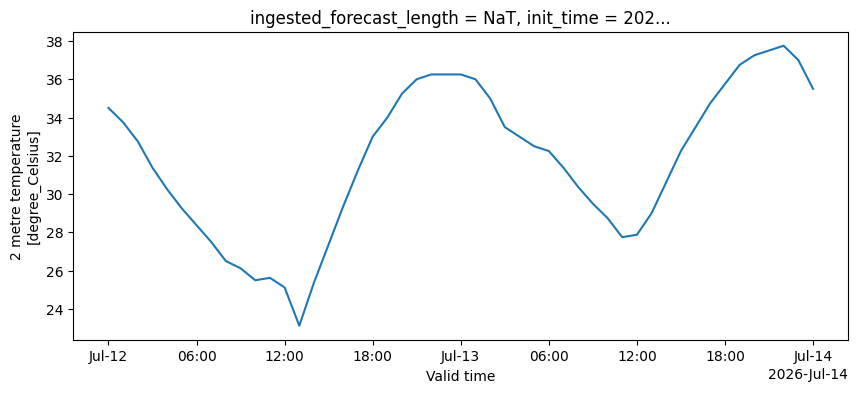

In [4]:
# Winnipeg, through the heat ridge of 11-13 July 2026
_ = ds["temperature_2m"].sel(init_time="2026-07-12T00").isel(**nearest_cell(49.90, -97.14)).plot(
    x="valid_time", figsize=(10, 4)
)

On a Lambert Conformal map the domain is a tilted rectangle. That tilt *is* the rotated grid.

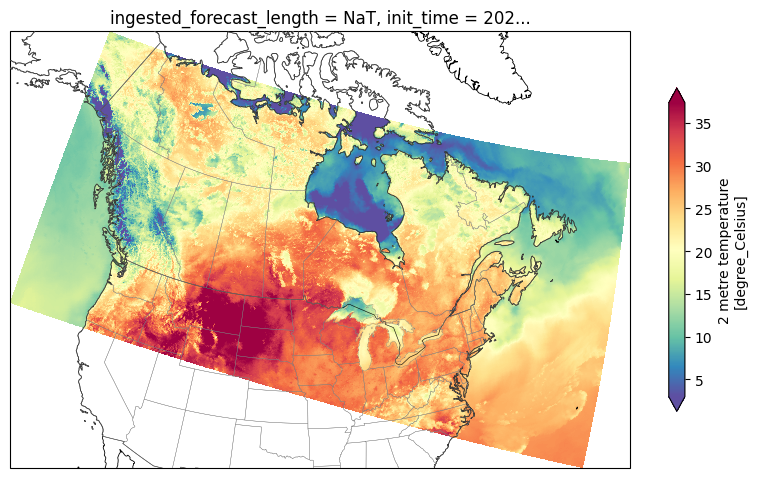

In [5]:
temperature = ds["temperature_2m"].sel(init_time="2026-07-12T00", lead_time="21h")
fig, ax = hrdps_map(figsize=(10, 6))
_ = temperature.coarsen(y=4, x=4, boundary="trim").mean().plot(
    ax=ax, transform=HRDPS_CRS, x="x", y="y", cmap="Spectral_r", robust=True,
    cbar_kwargs={"shrink": 0.7}
)

### Q1. What was the wind doing the night the Bald Range fire ran?

The Bald Range fire started northwest of Summerland, British Columbia on the afternoon of 7 August
2026 and burned about 5,000 hectares in three hours; BC Wildfire Service described a west wind
channelling it downhill. Here is 10 m wind over the Okanagan at the overnight peak, with Okanagan
Lake outlined for reference.

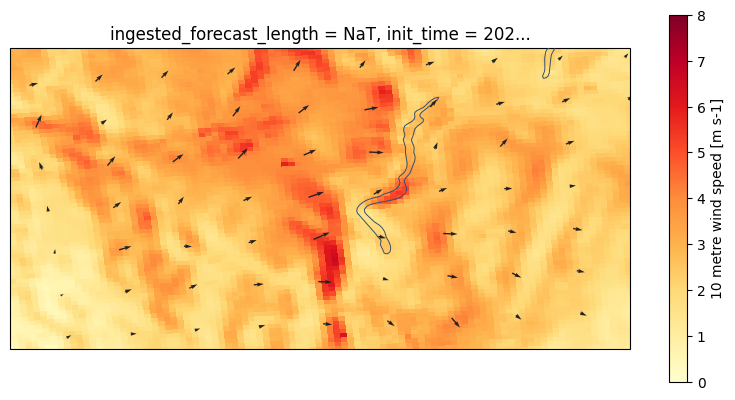

In [6]:
okanagan = latlon_box(
    ds[["wind_speed_10m", "wind_direction_10m"]].sel(init_time="2026-08-07T00", lead_time="28h"),
    west=-121.6, south=49.0, east=-118.3, north=50.6,
).load()

# Direction is degrees FROM, clockwise from true north
direction = np.deg2rad(okanagan["wind_direction_10m"])
u = -okanagan["wind_speed_10m"] * np.sin(direction)
v = -okanagan["wind_speed_10m"] * np.cos(direction)

fig, ax = hrdps_map([-121.6, -118.3, 49.0, 50.6], figsize=(10, 5.6),
                    scale="10m", projection=ccrs.PlateCarree())
# Natural Earth's coastlines skip Okanagan Lake, and the wind bands sort by which side of it
ax.add_feature(cfeature.NaturalEarthFeature("physical", "lakes_north_america", "10m"),
               facecolor="none", edgecolor="#33506e", linewidth=0.7, zorder=6)
okanagan["wind_speed_10m"].plot(ax=ax, transform=HRDPS_CRS, x="x", y="y", cmap="YlOrRd",
                                vmin=0, vmax=8, cbar_kwargs={"shrink": 0.85})
_ = ax.quiver(okanagan["longitude"][::10, ::10], okanagan["latitude"][::10, ::10],
              u[::10, ::10], v[::10, ::10], transform=ccrs.PlateCarree(),
              scale=180, width=0.0022, color="#222222", zorder=7)

### Q2. How dangerous did the fire weather get over the Thunder Bay 36 fire?

Thunder Bay 36 ignited on 12 July 2026 in Wabakimi Provincial Park in northwestern Ontario and ran
hard on 13-14 July. Relative humidity is not in the dataset, but temperature and dew point are, both
already in Celsius.

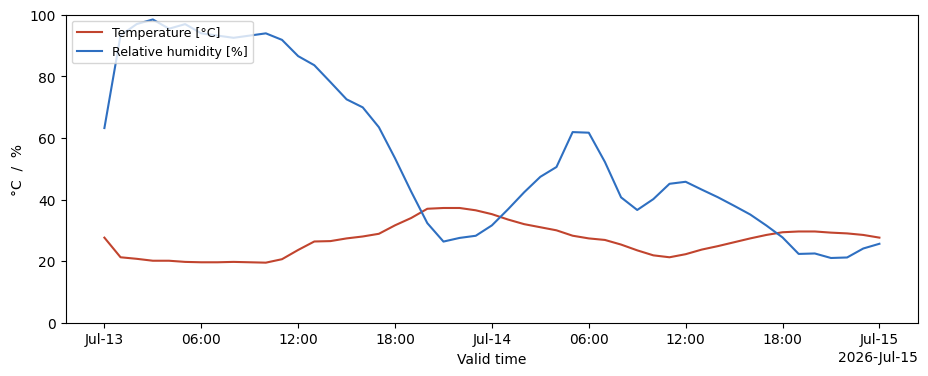

In [7]:
fire = ds[["temperature_2m", "dew_point_temperature_2m"]] \
    .sel(init_time="2026-07-13T00").isel(**nearest_cell(50.30, -89.02)).load()

a, b = 17.625, 243.04  # August-Roche-Magnus
gamma = lambda t: a * t / (b + t)
rh = 100 * np.exp(gamma(fire["dew_point_temperature_2m"]) - gamma(fire["temperature_2m"]))
rh.attrs = {"long_name": "Relative humidity", "units": "percent"}

fig, ax = plt.subplots(figsize=(11, 4))
fire["temperature_2m"].plot(ax=ax, x="valid_time", color="#c1442e", label="Temperature [°C]")
rh.plot(ax=ax, x="valid_time", color="#2e6fc1", label="Relative humidity [%]")
ax.set(ylim=(0, 100), ylabel="°C  /  %", title="")
_ = ax.legend(loc="upper left", fontsize=9)

### Q3. How hot did the Prairies get during the mid-July heat wave?

A heat ridge sat over the Prairies from 11 to 13 July 2026. A run spans 48 hours, so one forecast
holds the whole peak and reducing over `lead_time` gives the forecast maximum at every grid cell.

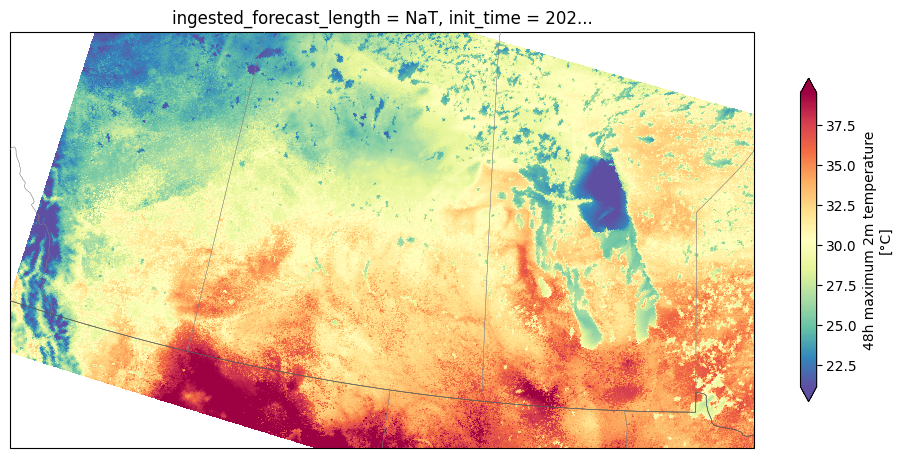

In [8]:
hottest = latlon_box(
    ds["temperature_2m"].sel(init_time="2026-07-12T00"), west=-115, south=48.3, east=-93.5, north=54.5
).max("lead_time").load()
hottest.attrs = {"long_name": "48h maximum 2m temperature", "units": "°C"}

fig, ax = hrdps_map([-115, -93.5, 48.3, 54.5], figsize=(12, 6))
_ = hottest.plot(ax=ax, transform=HRDPS_CRS, x="x", y="y", cmap="Spectral_r", robust=True,
                 cbar_kwargs={"shrink": 0.7})

### Q4. Where did the instability build before the 12 July storms?

Severe storms fired across the Prairies on the evening of 12 July 2026, in a season the Northern
Tornadoes Project was already calling well above average. CAPE carries source markers rather than
energies wherever there is no surface-based instability, so here is the same field raw and masked.

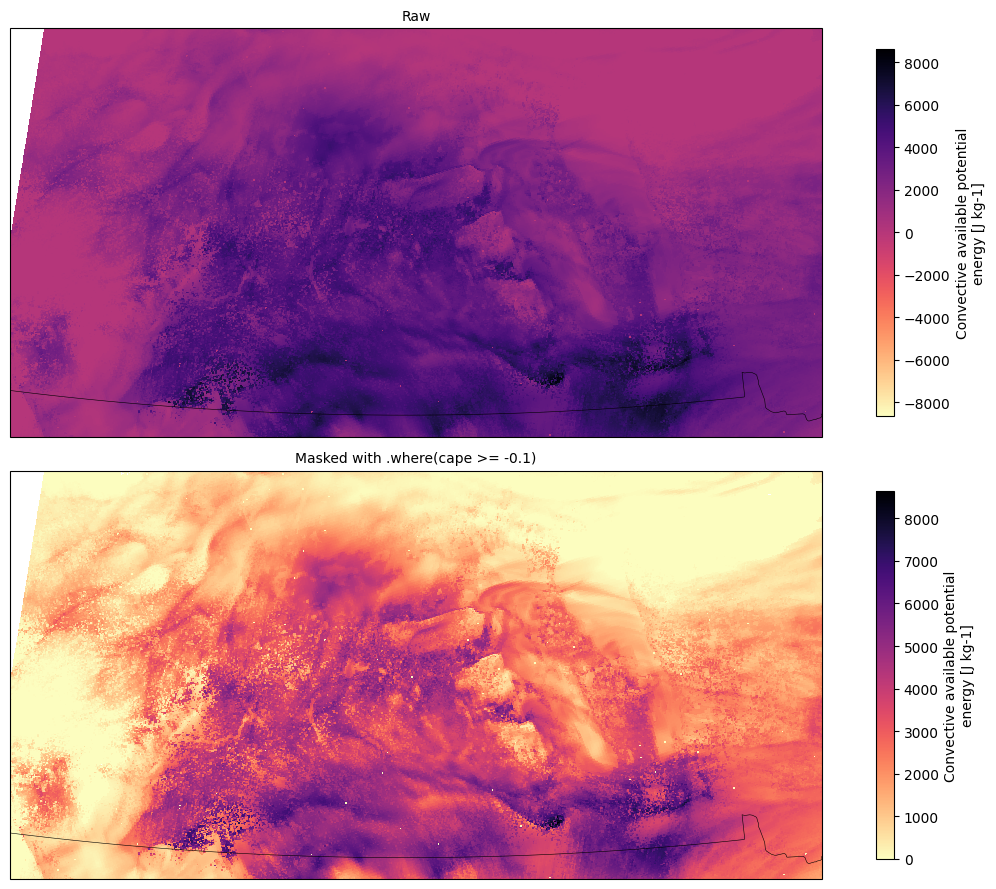

In [9]:
# Valid 2026-07-13 01 UTC, 7pm CDT
cape = latlon_box(
    ds["convective_available_potential_energy_surface"].sel(
        init_time="2026-07-12T00", lead_time="25h"),
    west=-112, south=48.3, east=-93.5, north=54.5,
).load()

fig, axes = plt.subplots(2, 1, figsize=(11, 9), subplot_kw={"projection": ccrs.LambertConformal(
    central_longitude=-103, central_latitude=51, standard_parallels=(49, 54))})
for ax, plot_da, title in [(axes[0], cape, "Raw"),
                           (axes[1], cape.where(cape >= -0.1), "Masked with .where(cape >= -0.1)")]:
    ax.set_extent([-112, -93.5, 48.3, 54.5], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    plot_da.plot(ax=ax, transform=HRDPS_CRS, x="x", y="y", cmap="magma_r",
                 cbar_kwargs={"shrink": 0.9})
    ax.set_title(title, fontsize=10)
fig.tight_layout()

### Q5. How much rain did the Maritimes get on 23-24 August?

Environment and Climate Change Canada issued a rainfall warning for Nova Scotia and southern New
Brunswick for 23-24 August 2026, for a slow-moving system with embedded thunderstorms.
Precipitation is a rate, so the hourly steps summed and scaled by the 3600-second step give an
accumulation.

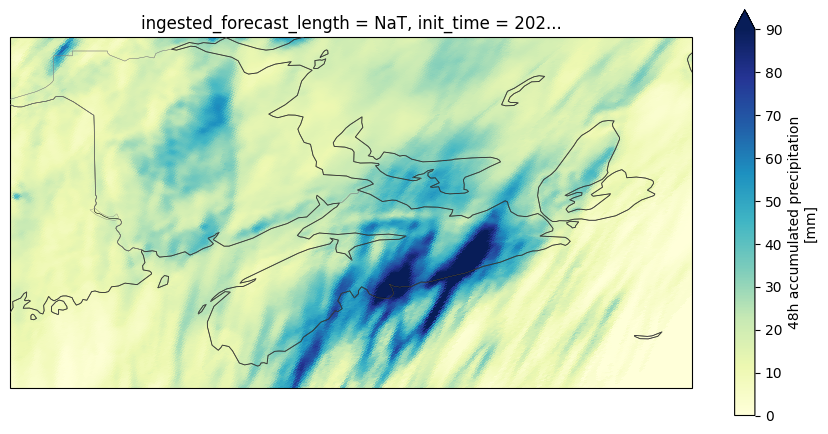

In [10]:
rate = latlon_box(
    ds["precipitation_surface"].sel(init_time="2026-08-23T00", lead_time=slice("1h", "48h")),
    west=-69, south=43.2, east=-59.3, north=48.2,
)
accumulated = (rate.sum("lead_time") * 3600).load()
accumulated.attrs = {"long_name": "48h accumulated precipitation", "units": "mm"}

fig, ax = hrdps_map([-69, -59.3, 43.2, 48.2], figsize=(11, 6.2), projection=ccrs.PlateCarree())
_ = accumulated.plot(ax=ax, transform=HRDPS_CRS, x="x", y="y", cmap="YlGnBu", vmin=0, vmax=90,
                     cbar_kwargs={"shrink": 0.85})

### Q6. Can the model see a lake breeze off Lake Superior?

Lake Superior is around 10 °C at the surface in mid-July, while northwestern Ontario was burning.
On the left, the field at 20 UTC on 13 July; on the right, the lakeshore cell at Thunder Bay against
one 80 km inland, from the same run.

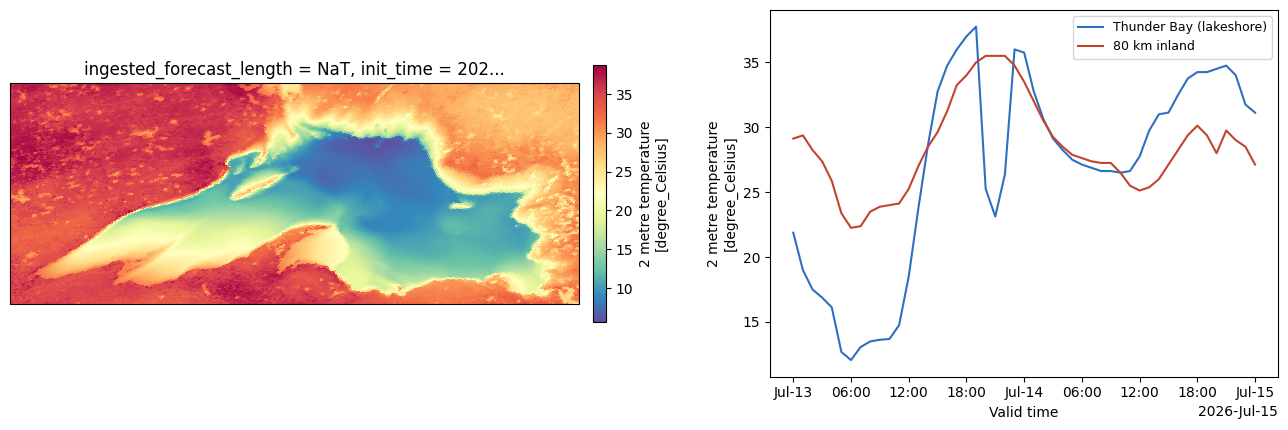

In [11]:
run = ds["temperature_2m"].sel(init_time="2026-07-13T00")
superior = latlon_box(run.sel(lead_time="20h"), west=-92.5, south=46.3, east=-84.0, north=49.6).load()
thunder_bay = run.isel(**nearest_cell(48.38, -89.25)).load()
inland = run.isel(**nearest_cell(49.10, -89.25)).load()

fig = plt.figure(figsize=(13, 4.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1])
ax_map = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax_map.set_extent([-92.5, -84.0, 46.3, 49.6], crs=ccrs.PlateCarree())
ax_map.coastlines(resolution="50m", linewidth=0.7, zorder=5)
superior.plot(ax=ax_map, transform=HRDPS_CRS, x="x", y="y", cmap="Spectral_r",
              cbar_kwargs={"shrink": 0.7, "pad": 0.02})

ax_ts = fig.add_subplot(gs[1])
thunder_bay.plot(ax=ax_ts, x="valid_time", color="#2e6fc1", label="Thunder Bay (lakeshore)")
inland.plot(ax=ax_ts, x="valid_time", color="#c1442e", label="80 km inland")
ax_ts.set_title("")
ax_ts.legend(fontsize=9)
fig.tight_layout()

### Q7 (animated). How did the 12 July Prairie storms evolve?

Hourly precipitation over the Prairies through the 12 July 00Z run, sampled every two hours.
Convection is resolved at 2.5 km rather than parameterized, so cells grow, merge and organize on
their own - here into two overnight systems with a nearly dry afternoon between them.

In [12]:
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

frames = latlon_box(
    ds["precipitation_surface"].sel(init_time="2026-07-12T00",
                                    lead_time=pd.timedelta_range("2h", "48h", freq="2h")),
    west=-112, south=48.3, east=-93.5, north=54.5,
).coarsen(y=2, x=2, boundary="trim").mean().load() * 3600  # kg m-2 s-1 is not a unit anyone reads in
frames.attrs = {"long_name": "Precipitation rate", "units": "mm h-1"}
raining = frames.where(frames > 0.05)  # dry cells would otherwise flood the colour scale
valid_times = pd.to_datetime(frames["valid_time"].values)

fig, ax = hrdps_map([-112, -93.5, 48.3, 54.5], figsize=(9.5, 4.4), dpi=72)
mesh = raining.isel(lead_time=0).plot(ax=ax, transform=HRDPS_CRS, x="x", y="y", cmap="turbo",
                                      vmin=0, vmax=12, cbar_kwargs={"shrink": 0.8})
title = ax.set_title("", fontsize=10)


def update(i):
    mesh.set_array(raining.isel(lead_time=i).values.ravel())
    title.set_text(f"{valid_times[i]:%Y-%m-%d %H} UTC")
    return mesh, title


anim = FuncAnimation(fig=fig, func=update, frames=frames["lead_time"].size, interval=200)
plt.close(fig)
HTML(anim.to_jshtml())

### Q8 (animated). What did the Okanagan wind surge look like in time?

The same wind as Q1, through the run rather than frozen at one hour. British Columbia is on PDT, so
subtract 7 hours from the labels.

In [13]:
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Read wider than we display so the rotated grid's edges stay off the map
gusts = latlon_box(
    ds["wind_gust_10m"].sel(init_time="2026-08-07T00",
                            lead_time=pd.timedelta_range("0h", "48h", freq="2h")),
    west=-122.6, south=48.5, east=-117.2, north=51.2,
).load()
gust_times = pd.to_datetime(gusts["valid_time"].values)

fig, ax = hrdps_map([-122.0, -117.8, 48.9, 50.8], figsize=(8.4, 4.4), scale="10m",
                    projection=ccrs.PlateCarree(), dpi=72)
ax.add_feature(cfeature.NaturalEarthFeature("physical", "lakes_north_america", "10m"),
               facecolor="none", edgecolor="#33506e", linewidth=0.7, zorder=6)
mesh = gusts.isel(lead_time=0).plot(ax=ax, transform=HRDPS_CRS, x="x", y="y", cmap="YlOrRd",
                                    vmin=0, vmax=16, cbar_kwargs={"shrink": 0.85})
title = ax.set_title("", fontsize=10)


def update(i):
    mesh.set_array(gusts.isel(lead_time=i).values.ravel())
    title.set_text(f"{gust_times[i]:%Y-%m-%d %H} UTC")
    return mesh, title


anim = FuncAnimation(fig=fig, func=update, frames=gusts["lead_time"].size, interval=220)
plt.close(fig)
HTML(anim.to_jshtml())

### Q9 (animated). What does 48 hours of the whole domain look like?

Two diurnal cycles across the full 2.5 km domain during the same heat wave, coarsened 5x.

In [14]:
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

continent = ds["temperature_2m"].sel(
    init_time="2026-07-13T00", lead_time=pd.timedelta_range("0h", "48h", freq="3h")
).coarsen(y=5, x=5, boundary="trim").mean().load()
continent_times = pd.to_datetime(continent["valid_time"].values)

fig, ax = hrdps_map([-140, -52, 38, 70], figsize=(7.8, 4.6), dpi=72)
mesh = continent.isel(lead_time=0).plot(ax=ax, transform=HRDPS_CRS, x="x", y="y",
                                        cmap="Spectral_r", vmin=-5, vmax=40,
                                        cbar_kwargs={"shrink": 0.8})
title = ax.set_title("", fontsize=10)


def update(i):
    mesh.set_array(continent.isel(lead_time=i).values.ravel())
    title.set_text(f"{continent_times[i]:%Y-%m-%d %H} UTC")
    return mesh, title


anim = FuncAnimation(fig=fig, func=update, frames=continent["lead_time"].size, interval=260)
plt.close(fig)
HTML(anim.to_jshtml())

### Community challenge

- **Rank the season's fire-weather windows.** Build a Hot-Dry-Windy index across the domain from
  vapour pressure deficit and wind speed, and find the worst 6-hour windows in the archive. How much
  warning did HRDPS give before Thunder Bay 36 and Bald Range made their runs?
- **Forecast turbine output at hub height.** `wind_speed_80m` is unusually close to modern hub
  heights. Convert it to power for the Prairie wind fleet and compare against `wind_speed_10m` with
  a shear assumption. How much does the shortcut cost?
- **Measure how much the model changes its mind.** One valid time is covered by up to eight
  forecasts of different ages. Stack every `init_time` reaching a convective afternoon and quantify
  how the precipitation field converges as lead time shortens.
- **Cross-check against radar.** Compare Q5's accumulation with `noaa-mrms-conus-analysis-hourly`
  where the domains overlap. Does HRDPS put the bands in the right place, or the right amount in the
  wrong place?

> **Draft note — recommendations. Delete before publishing.**
>
> **Keep Q1, Okanagan wind.** The strongest argument for 2.5 km here, and it carries the
> speed-and-direction convention, which is the dataset's most surprising choice.
>
> **Keep Q6, Lake Superior lake breeze.** A 12-degree drop in an hour at the shoreline with nothing
> 80 km inland. Pairs with Q1 by showing a different mechanism.
>
> **Keep Q7 as the animation.** Two nocturnal systems with a dry afternoon between them - behaviour
> a parameterized model gets structurally wrong, so it argues for the model rather than just looking
> good.
>
> **The cuts.** Q2 is the best of the rest and the one I'd restore if a third static were allowed.
> Q3 is the most legible and least analytical. Q4 is a data-hygiene lesson the structure note
> already covers. Q5 is the only section tied to a published warning, which is a real loss -
> reconsider it if verification matters more than resolution. Q8 repeats Q1's event; Q9 is the
> prettiest and least informative.
>
> **Open items.** `ingested_forecast_length` is all-NaT for every init time and is dropped in the
> open cell so plot titles don't read "NaT" - better fixed upstream. The open cell swaps to
> `dynamical_catalog.open("eccc-hrdps-forecast", chunks=None)` once the collection is published.